In [1]:
import sys
import os

# Set path
project_root = os.path.abspath('.')
while not os.path.exists(os.path.join(project_root, 'requirements.txt')):
    project_root = os.path.dirname(project_root)
    if project_root == os.path.dirname(project_root):
        raise FileNotFoundError("can't find root path")

os.chdir(project_root)
print(f"Working directory set to project root: {os.getcwd()}")

from utilities.plotting import run_analysis_and_generate_plots

results_to_analyze_dir_SW = os.path.join(project_root, "results", "synthetic", "SmallWorld")
results_to_analyze_dir_SB = os.path.join(project_root, "results", "synthetic", "StochasticBlock")
results_to_analyze_dir_SF = os.path.join(project_root, "results", "synthetic", "ScaleFree")

# This is the directory where the output plots will be saved.
output_plots_dir = os.path.join(project_root, "plots")

# Ensure the output directory exists before running the analysis.
os.makedirs(output_plots_dir, exist_ok=True)
print(f"plots will be saved in: {output_plots_dir}")


Working directory set to project root: /scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests
plots will be saved in: /scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests/plots


# 3. Scale Free

## 3.1 Different Gamma (Scale Free, Cov_Sign = Positive)


Running analysis for: Power vs. Number of Nodes for Different Gammas with 95% CI (Cov_Sign = Pos)
--- Starting to load all summary reports from '/scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests/results/synthetic/ScaleFree/ScaleFree_Gamma_Pos' ---
All summary reports loaded successfully.
Calculating power for all 8 scenarios...
All calculations complete.
Generating plots...


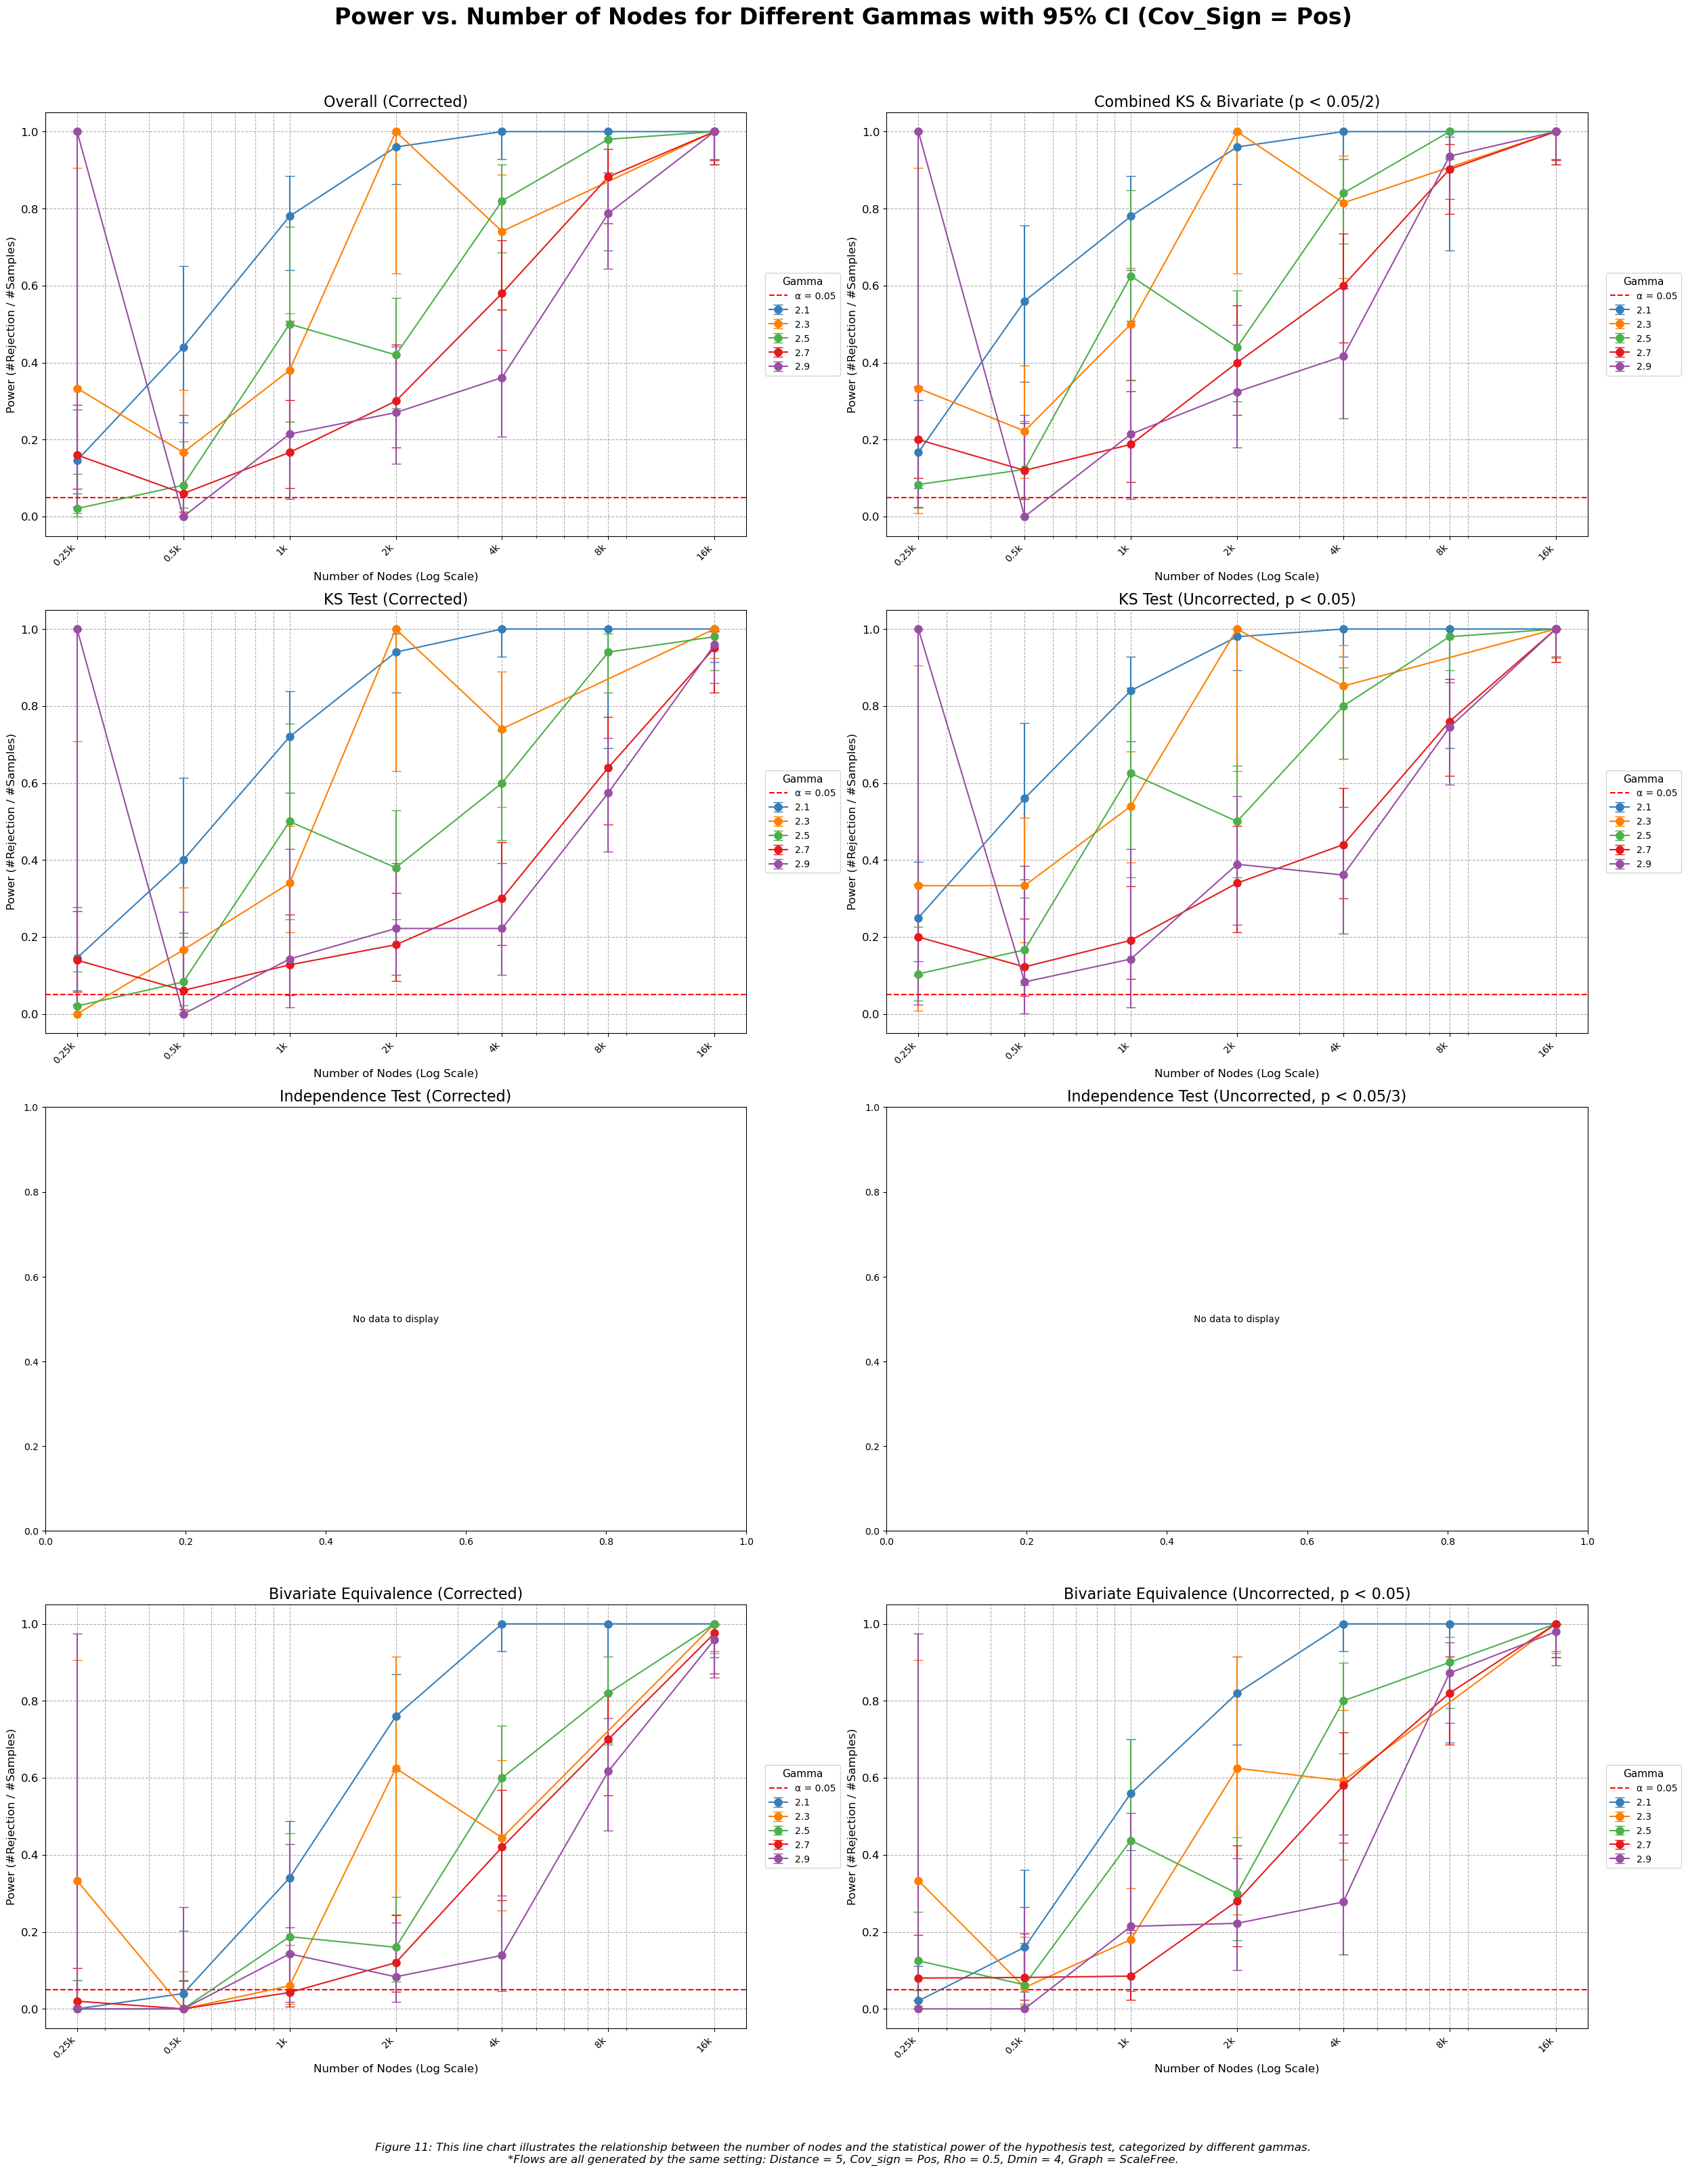

Analysis complete. Figures saved as '/scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests/plots/figure12_power_gamma_scalefree_pos.pdf/.png'.


In [2]:
specific_result_folder = "ScaleFree_Gamma_Pos"
plot_name = "figure12_power_gamma_scalefree_pos"

full_results_path = os.path.join(results_to_analyze_dir_SF, specific_result_folder)
filename_base = os.path.join(output_plots_dir, plot_name)

run_analysis_and_generate_plots({
        "root_dir": full_results_path,
        "group_by_col": "gamma",
        "legend_title": "Gamma",
        "palette": {2.1: '#377eb8', 2.3: '#ff7f00', 2.5: '#4daf4a', 2.7: '#e41a1c', 2.9: '#984ea3'},
        "main_title": 'Power vs. Number of Nodes for Different Gammas with 95% CI (Cov_Sign = Pos)',
        "caption": ("Figure 11: This line chart illustrates the relationship between the number of nodes and the statistical power "
                    "of the hypothesis test, categorized by different gammas."
                    "\n*Flows are all generated by the same setting: Distance = 5, Cov_sign = Pos, Rho = 0.5, Dmin = 4, Graph = ScaleFree.\n"),
                    # "#Classification: Top 25% Edge Degree to class1; Bottom 25% Edge Degree to class2."),
        "filename_base": filename_base
    })

We see that graphs that have at least 2k nodes where gamma=2.1 consistently result in a power close to or equal to 1. On the other hand, graphs where gamma=2.9 don't result in a power of 1 until they have at least 16k nodes. Scale-free graphs where gamma approaches 2 have hubs whose nodes have a degree that is much greater than the average node degree of the graph. Graphs where gamma approaches 3 do not have hubs that are as prominent. The highest degrees of nodes in these graphs are not much larger than the average degree of the graph. Therefore, we should be looking for graphs that resemble synthetic scale free networks with a gamma of 2.1.

## 3.2 Different Weight SF


Running analysis for: Power vs. Number of Nodes for Different Weights with 95% CI (Cov_Sign = Pos)
--- Starting to load all summary reports from '/scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests/results/synthetic/ScaleFree/ScaleFree_Weight_SF_Pos' ---
All summary reports loaded successfully.
Calculating power for all 8 scenarios...
All calculations complete.
Generating plots...


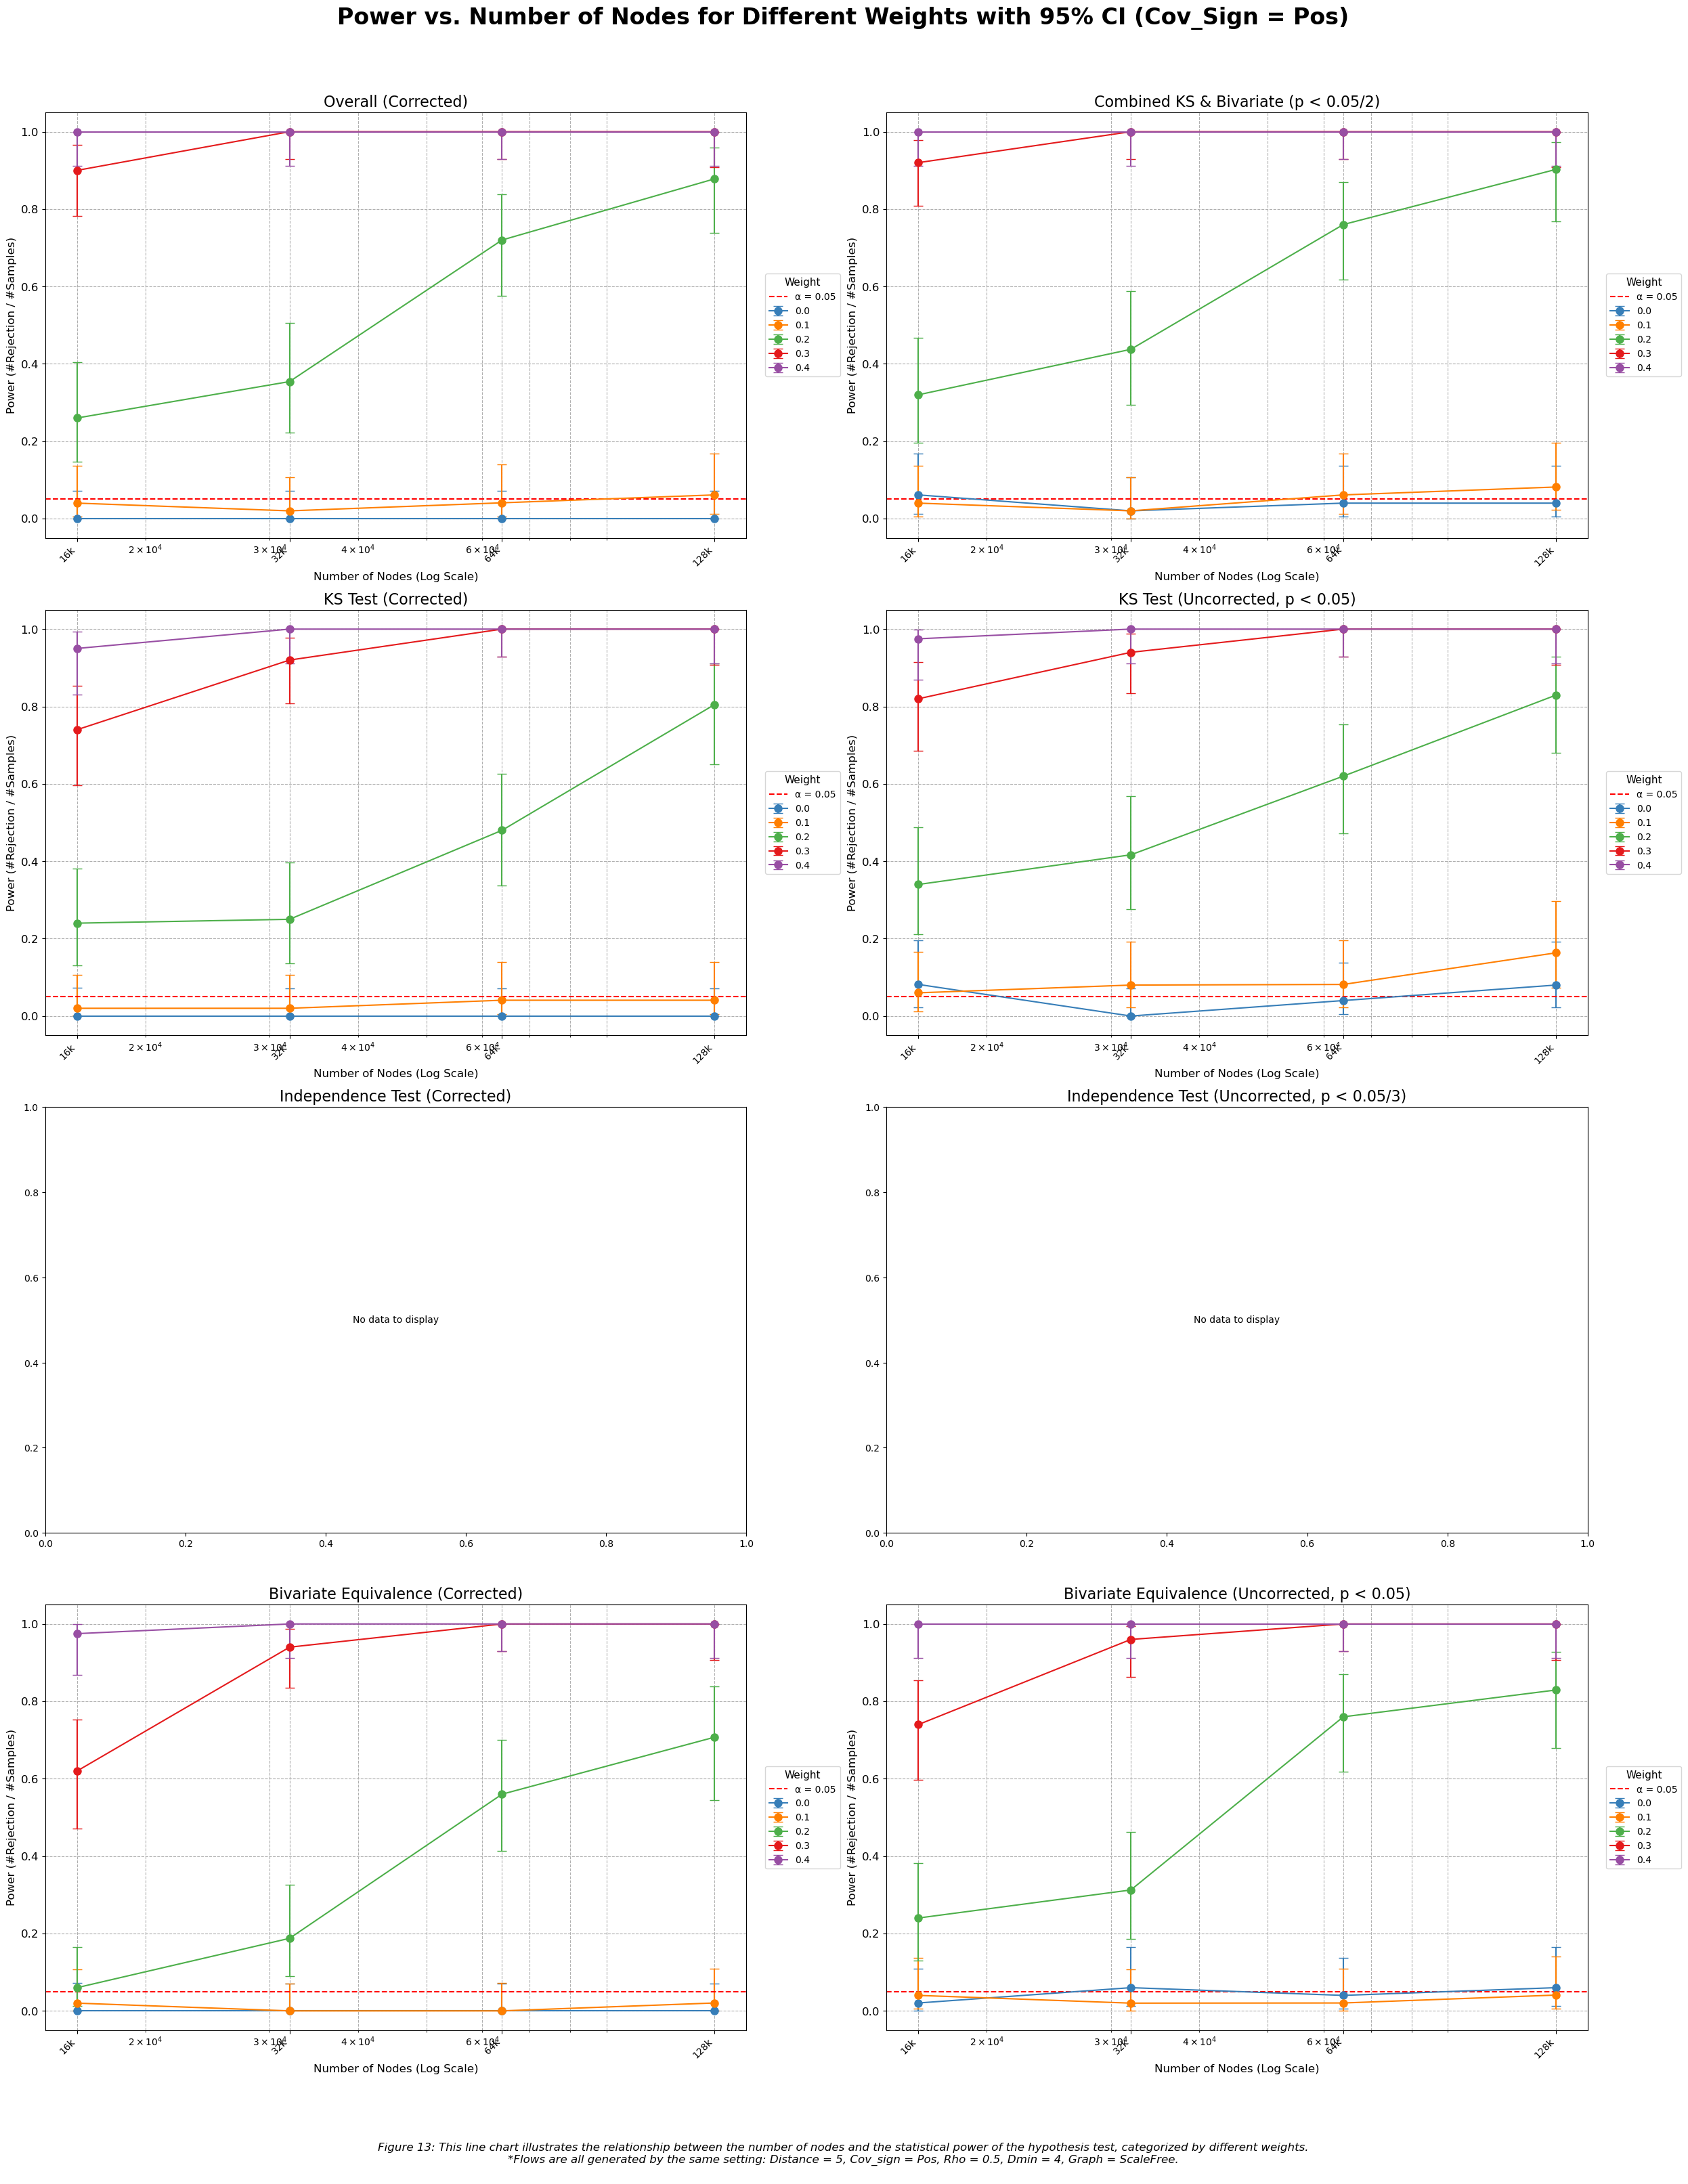

Analysis complete. Figures saved as '/scratch/users/sharonasyang/Edge-Flow-Hypothesis-Tests/plots/figure13_power_weight_scalefree_pos.pdf/.png'.


In [3]:
specific_result_folder = "ScaleFree_Weight_SF_Pos"
plot_name = "figure13_power_weight_scalefree_pos"

full_results_path = os.path.join(results_to_analyze_dir_SF, specific_result_folder)
filename_base = os.path.join(output_plots_dir, plot_name)

run_analysis_and_generate_plots({
        "root_dir": full_results_path,
        "group_by_col": "W",
        "legend_title": "Weight",
        "palette": {0: '#377eb8', 0.1: '#ff7f00', 0.2: '#4daf4a', 0.3: '#e41a1c', 0.4: '#984ea3'},
        "main_title": 'Power vs. Number of Nodes for Different Weights with 95% CI (Cov_Sign = Pos)',
        "caption": ("Figure 13: This line chart illustrates the relationship between the number of nodes and the statistical power "
                    "of the hypothesis test, categorized by different weights."
                    "\n*Flows are all generated by the same setting: Distance = 5, Cov_sign = Pos, Rho = 0.5, Dmin = 4, Graph = ScaleFree.\n"),
                    # "#Classification: Top 25% Edge Degree to class1; Bottom 25% Edge Degree to class2."),
        "filename_base": filename_base
    })

The graphs with at least 32k nodes where weight=0.3 or 0.4 results in a power close to 1 while graphs where weight=0 or 0.1 result in a power close to 0 consistently. Similar to the reasoning why decreasing gamma increases power, increasing weight increases power. Therefore, we should be looking for graphs that resemble synthetic scale free networks with a weight of 0.4.